How is this measurement, reported by Canfranc, correlated with the background rate that we detect within NEXT-100 fiducial volume?

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

from   datetime import datetime
from   iminuit      import Minuit               # type: ignore
from   iminuit.cost import LeastSquares         # type: ignore
from   matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from   PIL import Image                         # type: ignore
import scipy

# Styling Plot
pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preliminary

In [16]:
# ----- Configuration ----- #
VERSION_TAG = 'p2_final'      # Options: 'rescale_p1', 'p2_final'
SUMMARY_FILENAME = 'summary_' + VERSION_TAG +'.csv'     # Choose your name

DATA_PERIOD = 2                 # Options: 1, 2
DETECTOR_CONDITION = 'castle_closed_RAS'       # Options: None, 'castle_open', 'castle_closed', 'castle_closed_RAS', 'castle_pclosed', 'castle_pclosed_RAS'

RESCALE_FACTOR_PERIOD_1 = 0.8851
FIDUCIAL_EFF_STD = 8e-3       # Standard fiducial efficiency for correction

# ----- Detector Conditions Dates ----- #
# Period 01
CPC_RAS = 1746791100      # Castle = partially closed & RAS = on
CPC     = 1747042200      # Castle = partially closed & RAS = off
CC_RAS  = 1749024786      # Castle = closed & RAS = on
# Period 02
CC_02      = 1753092000   # Castle = closed & RAS = off
CC_RAS_02  = 1754035200   # Castle = closed & RAS = on

# ----- Dates ----- #
SEP_2025 = 1756764000     # 2nd September 2025

## LSC Files

In [3]:
# # Folder with text files
TXT_DIR  = "/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/"

# ----- LSC Reports ----- #
# RAS = off
# LSC_FILENAMES_01 = ['radon_HALLA_05052025_12052025.txt', 'radon_HALLA_12052025_19052025.txt','radon_HALLA_19052025_27052025.txt', 'radon_HALLA_27052025_02062025.txt']
# LSC_FILENAMES_02 = ['radon_HALLA_21072025_28072025.txt', 'radon_HALLA_28072025_04082025.txt']

# RAS = on
LSC_FILENAMES_02 = ['radon_HALLA_04082025_11082025.txt', 'radon_HALLA_11082025_18082025.txt', 'radon_HALLA_18082025_25082025.txt', 'radon_HALLA_25082025_01092025.txt']

## Runs & Summary Information

In [4]:
# ----- Main Directories ----- #
RUNS_INFO_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/'
SUMMARY_DIR   = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/'

# ----- Load Dataframes ----- #
RUNS_INFO_DF = pd.read_csv(os.path.join(RUNS_INFO_DIR, f'runs_information.csv'))
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()

SUMMARY_DF   = pd.read_csv(os.path.join(SUMMARY_DIR, SUMMARY_FILENAME))
SUMMARY_DF.drop(columns=['Unnamed: 0'], inplace=True)
SUMMARY_DF.columns = SUMMARY_DF.columns.str.strip()
SUMMARY_DF.sort_values(by='Run_ID', inplace=True)

In [5]:
selection_mask = pd.Series(True, index=RUNS_INFO_DF.index)

runs_in_summary = SUMMARY_DF['Run_ID'].unique()
print(f"→ Must be one of the {len(runs_in_summary)} runs in the summary.")
selection_mask &= RUNS_INFO_DF['run_number'].isin(runs_in_summary)

if DATA_PERIOD is not None:
    print(f"→ Period == {DATA_PERIOD}")
    # The '&=' operator is a shortcut for 'selection_mask = selection_mask & ...'
    selection_mask &= (RUNS_INFO_DF['period'] == DATA_PERIOD)

if DETECTOR_CONDITION is not None:
    print(f"→ Condition == '{DETECTOR_CONDITION}'")
    selection_mask &= (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION)

RUNS_TO_ANALYZE = RUNS_INFO_DF.loc[selection_mask, 'run_number'].values
print(f"\nSelected {len(RUNS_TO_ANALYZE)} runs for analysis:\n{RUNS_TO_ANALYZE}")

→ Must be one of the 67 runs in the summary.
→ Period == 2
→ Condition == 'castle_closed_RAS'

Selected 56 runs for analysis:
[15625 15626 15627 15632 15633 15634 15635 15636 15637 15639 15640 15642
 15643 15644 15645 15647 15648 15649 15650 15655 15656 15657 15658 15659
 15669 15670 15671 15672 15673 15675 15676 15681 15682 15687 15688 15689
 15693 15694 15695 15696 15697 15698 15699 15700 15701 15709 15724 15729
 15730 15731 15732 15733 15734 15735 15736 15737]


## Rates Dataframe

In [6]:
rates_info_columns = ['Run_ID', 'Duration', 'Date_CV', 'Date_Err', 'OK', 'LOST', 'Reconstructed', 'nElectron_Fiducial']
RATES_DF = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'].isin(RUNS_TO_ANALYZE), rates_info_columns]
RATES_DF.sort_values(by='Run_ID', inplace=True)
RATES_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,nElectron_Fiducial
11,15625,87329,1.754086e+09,179.1256,30498,8570,30122,270
12,15626,107092,1.754183e+09,198.8003,37665,10446,37257,330
13,15627,61872,1.754268e+09,149.3707,21967,6238,21692,172
14,15632,86709,1.754356e+09,176.5448,30444,8826,30078,259
15,15633,86076,1.754442e+09,177.5632,30070,8578,29744,227
16,15634,86545,1.754529e+09,177.8670,30372,8234,30034,229
17,15635,87672,1.754616e+09,176.2725,30697,8537,30372,222
18,15636,84284,1.754702e+09,174.6968,29394,8465,29123,223
19,15637,76285,1.754782e+09,166.4730,26571,7422,26326,205
20,15639,87347,1.754872e+09,178.7687,30861,8525,30503,261


Pueden que hayan algunas exclusiones

In [7]:
# Exclusion criterias
excluded_runs  = {15625, 15626, 15627}
date_threshold = SEP_2025

# Masks
exclusion_mask = ~RATES_DF['Run_ID'].isin(excluded_runs)
date_mask      = RATES_DF['Date_CV'] <= date_threshold

# ----- Final Dataframe ----- #
RATES_DF = RATES_DF.loc[exclusion_mask & date_mask].copy()
RATES_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,nElectron_Fiducial
14,15632,86709,1.754356e+09,176.5448,30444,8826,30078,259
15,15633,86076,1.754442e+09,177.5632,30070,8578,29744,227
16,15634,86545,1.754529e+09,177.8670,30372,8234,30034,229
17,15635,87672,1.754616e+09,176.2725,30697,8537,30372,222
18,15636,84284,1.754702e+09,174.6968,29394,8465,29123,223
19,15637,76285,1.754782e+09,166.4730,26571,7422,26326,205
20,15639,87347,1.754872e+09,178.7687,30861,8525,30503,261
21,15640,30714,1.754931e+09,105.0039,10700,3170,10565,93
22,15642,25075,1.754963e+09,95.9453,8722,2437,8635,64
23,15643,89049,1.755020e+09,180.1138,31554,8674,31248,245


## Dictionaries Definition

In [8]:
# ----- Fiducial Info Dictionary ----- #
Fiducial_Info = {
                    run_id: {"start": 0, "end": 0, "rate_CV": 0, "rate_Error": 0} 
                    for run_id in RATES_DF['Run_ID'].unique()
                }
Fiducial_Info

{15632: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15633: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15634: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15635: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15636: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15637: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15639: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15640: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15642: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15643: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15644: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15645: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15647: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15648: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15649: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Error': 0},
 15650: {'start': 0, 'end': 0, 'rate_CV': 0, 'rate_Erro

In [9]:
# Store here the information of the LSC report
LSC_Report = {
                    'Date':   [],       # In format 'DD/MM/DD:HH:MM:SS' but converted to epoch time [s]
                    'Rn_CV':  [],       # In [Bq/m^3]
                    'Rn_Err': []        # In [Bq/m^3]
             }

# Fiducial Information

In [17]:
for run_id in RATES_DF['Run_ID'].unique():

    print(f'Processing Run {run_id}:')
    
    # Run information
    duration = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Duration'].values[0]
    OK_trg   = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'OK'].values[0]
    LOST_trg = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'LOST'].values[0]
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = ff.efficiency(OK_trg, LOST_trg)

    # --- Time Information --- #
    date_cv = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Date_CV'].values[0]
    Fiducial_Info[run_id]['start'] = date_cv - (duration/2)
    Fiducial_Info[run_id]['end']   = date_cv + (duration/2)

    # Fiducial events + error
    fidu_evts  = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'nElectron_Fiducial'].values[0];    fidu_evts = int(fidu_evts)
    fidu_CV, fidu_var = scipy.stats.binom.stats(n=OK_trg, p=fidu_evts/OK_trg, moments='mv')

    # ----- Rate Correction ----- #
    if DATA_PERIOD == 1:
        corr_factor = RESCALE_FACTOR_PERIOD_1
    elif run_id in [15655, 15656, 15657, 15658, 15659]:
        eff_fid, eff_err = ff.efficiency(fidu_CV, OK_trg - fidu_CV)    # Fiducial efficiency + error
        corr_factor = FIDUCIAL_EFF_STD / eff_fid
        print(f'  Run {run_id} - Correction Factor = {corr_factor:.4f}')
    else:
        corr_factor = 1.0

    fidu_CV  *= corr_factor
    fidu_var *= corr_factor**2
    
    # Fiducial rate + error for each run
    rate_CV  = fidu_CV / (duration * DAQe_CV)
    rate_err = rate_CV * np.sqrt((np.sqrt(fidu_var) / fidu_CV)**2 + (DAQe_error / DAQe_CV)**2)

    Fiducial_Info[run_id]['rate_CV']    = rate_CV*1e3        # In [mHz]
    Fiducial_Info[run_id]['rate_Error'] = rate_err*1e3       # In [mHz]

    print(f'  Rate = {rate_CV*1e3:.4f} ± {rate_err*1e3:.4f} mHz\n')

Processing Run 15632:
  Rate = 3.8530 ± 0.2386 mHz

Processing Run 15633:
  Rate = 3.3895 ± 0.2243 mHz

Processing Run 15634:
  Rate = 3.3634 ± 0.2216 mHz

Processing Run 15635:
  Rate = 3.2364 ± 0.2166 mHz

Processing Run 15636:
  Rate = 3.4078 ± 0.2275 mHz

Processing Run 15637:
  Rate = 3.4379 ± 0.2394 mHz

Processing Run 15639:
  Rate = 3.8135 ± 0.2353 mHz

Processing Run 15640:
  Rate = 3.9250 ± 0.4056 mHz

Processing Run 15642:
  Rate = 3.2655 ± 0.4070 mHz

Processing Run 15643:
  Rate = 3.5076 ± 0.2234 mHz

Processing Run 15644:
  Rate = 3.6600 ± 0.2326 mHz

Processing Run 15645:
  Rate = 3.8151 ± 0.2372 mHz

Processing Run 15647:
  Rate = 3.3657 ± 0.2218 mHz

Processing Run 15648:
  Rate = 4.1288 ± 0.2454 mHz

Processing Run 15649:
  Rate = 3.9919 ± 0.2412 mHz

Processing Run 15650:
  Rate = 3.4672 ± 0.4463 mHz

Processing Run 15655:
  Run 15655 - Correction Factor = 1.3715
  Rate = 3.6394 ± 0.2801 mHz

Processing Run 15656:
  Run 15656 - Correction Factor = 1.1863
  Rate = 3.6

# LSC Report

Be careful here, for some reason the LSC data structure change from period 01 to period 02.
<br>
I upload the LSC data by period.

#### Period 01

In [39]:
# ----- PERIOD 01 ----- #
for filename in LSC_FILENAMES_01:

    print("----- PERIOD 01 -----")
    
    file_path = os.path.join(TXT_DIR, filename)
    df = pd.DataFrame()

    print(f"Processing file: {os.path.basename(file_path)}")

    # Read the .txt file into a DataFrame
    try:
        df = pd.read_csv(file_path, sep='\t', encoding='latin1')
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        continue
   
    for j in range(len(df.columns)):

        if j % 8 == 0:
            parts = df.iloc[:, j].name.split()
            if len(parts) < 3:
                print(f"   Warning: Missing time in column {j}. Adding '0:00:00' to {parts}")
                parts.append('0:00:00')                                                         # Default time if not provided (every start of day)

            # Store the date in epoch time  
            date = str(parts[1]) + ' ' + str(parts[2])                                          # Here we avoid the entry 0 that is relative humidity
            epoch_time = datetime.strptime(date, "%d/%m/%Y %H:%M:%S").timestamp()
            LSC_Report['Date'].append(epoch_time)
        
        if j % 8 == 1 and df.iloc[:, j].name != 'no data':
            LSC_Report['Rn_CV'].append(float(df.iloc[:, j].name))

        if j % 8 == 5 and df.iloc[:, j].name != 'no data':
            LSC_Report['Rn_Err'].append(float(df.iloc[:, j].name))

----- PERIOD 01 -----
Processing file: radon_HALLA_05052025_12052025.txt
----- PERIOD 01 -----
Processing file: radon_HALLA_12052025_19052025.txt
----- PERIOD 01 -----
Processing file: radon_HALLA_19052025_27052025.txt
----- PERIOD 01 -----
Processing file: radon_HALLA_27052025_02062025.txt


#### Period 02

In [11]:
# ----- PERIOD 02 ----- #
for filename in LSC_FILENAMES_02:

    print("----- PERIOD 02 -----")
    
    file_path = os.path.join(TXT_DIR, filename)
    df = pd.DataFrame()

    print(f"Processing file: {os.path.basename(file_path)}")

    # Read the .txt file into a DataFrame
    try:
        df = pd.read_csv(file_path, sep='\t', encoding='latin1')
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        continue

    # Extract relevant columns
    try:
        measurement_time = df['Measurement time']
        rn_concentration = df['Rn222 (Bq/m3) AG2078  [DVD]']
        rn_error = df['Add 1.0 function for Rn222+error in Bq AG2078  [DVD] (Bqm3) ']       # DO NOT CHANGE NOTHING HERE!
    except KeyError as e:
        print(f"Error: Missing expected column {e} in file {file_path}. Skipping this file.")
        continue

    # Ensure all entries in 'Measurement time' have a time component
    measurement_time = measurement_time.apply(lambda x: x if len(x.split()) > 1 else f"{x} 0:00:00")

    # Convert measurement time to epoch and store data
    for time, concentration, error in zip(measurement_time, rn_concentration, rn_error):
        try:
            epoch_time = datetime.strptime(time, "%d/%m/%Y %H:%M:%S").timestamp()
            LSC_Report['Date'].append(epoch_time)
            LSC_Report['Rn_CV'].append(float(concentration))
            LSC_Report['Rn_Err'].append(float(error))
        except ValueError as e:
            print(f"Error processing row with time {time}: {e}")
            continue    

----- PERIOD 02 -----
Processing file: radon_HALLA_04082025_11082025.txt
----- PERIOD 02 -----
Processing file: radon_HALLA_11082025_18082025.txt
----- PERIOD 02 -----
Processing file: radon_HALLA_18082025_25082025.txt
----- PERIOD 02 -----
Processing file: radon_HALLA_25082025_01092025.txt


#### Are those errors uncorrelated?

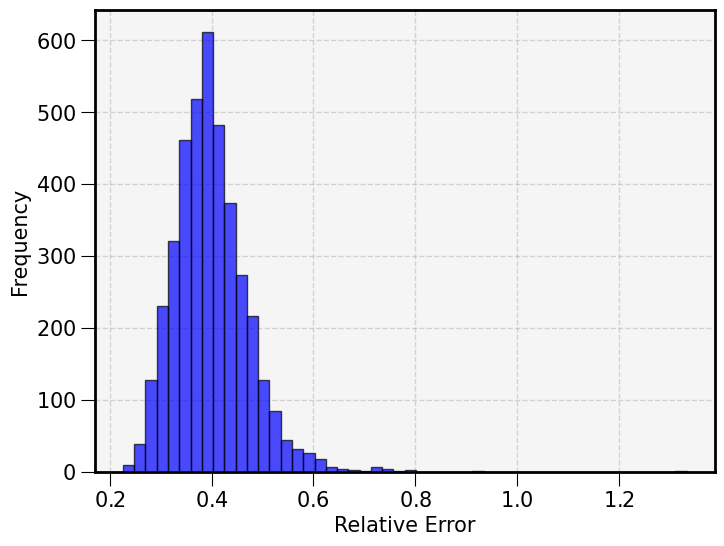

In [26]:
# List of corresponding relative errors
Error_rel = np.array(LSC_Report['Rn_Err']) / np.array(LSC_Report['Rn_CV'])

# ----- Plotting ----- #
plt.figure(figsize=(8, 6))
plt.hist(Error_rel, bins=50, color='blue', alpha=0.7, edgecolor='black', lw=1.0, zorder=3)
plt.xlabel('Relative Error')
plt.ylabel('Frequency')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

## Representative Points

Let's plot all the LSC data and obtain a representative value per run.

In [40]:
print(Fiducial_Info)

{15299: {'start': 1747064858.0205, 'end': 1747125062.0205, 'rate_CV': 5.453238186347167, 'rate_Error': 0.3446835949238222}, 15318: {'start': 1747151112.9061, 'end': 1747237818.9061, 'rate_CV': 4.343125543190017, 'rate_Error': 0.21274542614534722}, 15319: {'start': 1747237802.9218, 'end': 1747323625.9218, 'rate_CV': 3.9533448079224347, 'rate_Error': 0.20420843078448697}, 15330: {'start': 1747661258.8827, 'end': 1747747720.8827, 'rate_CV': 3.9385597992241013, 'rate_Error': 0.20317667664265682}, 15331: {'start': 1747748221.9681, 'end': 1747833610.9681, 'rate_CV': 4.933829923918702, 'rate_Error': 0.26286527446048724}, 15332: {'start': 1747833878.5003, 'end': 1747901636.5003, 'rate_CV': 4.974765800072709, 'rate_Error': 0.296987977070338}, 15462: {'start': 1747928561.8589, 'end': 1747967926.8589, 'rate_CV': 4.22785363852608, 'rate_Error': 0.3571649089173247}, 15472: {'start': 1748004744.1595, 'end': 1748091307.1595, 'rate_CV': 3.767899688147817, 'rate_Error': 0.19848991405394636}, 15478: {'s

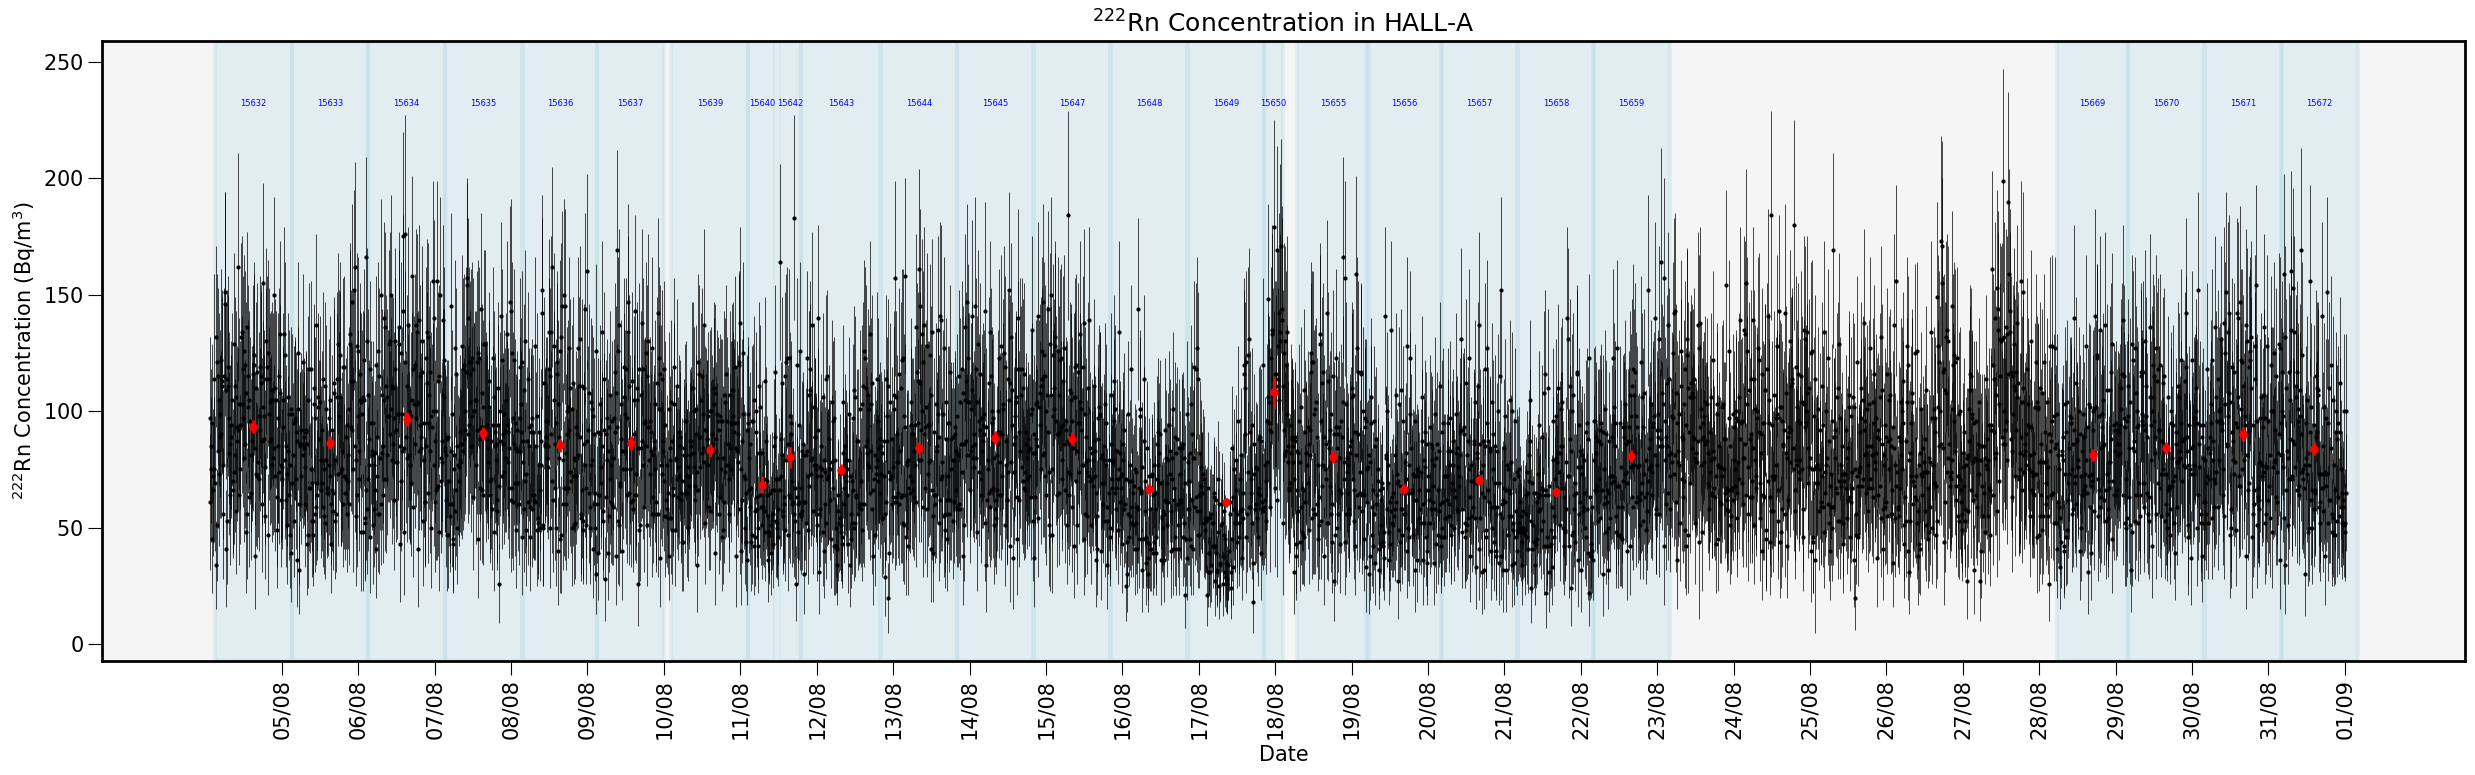

In [12]:
# Global
Date_LSC_CV  = []
Date_LSC_Err = []
Rn_LSC_CV    = []
Rn_LSC_Err   = []

plt.figure(figsize=(25, 8))

# ----- Runs Loop ----- #
for run_id in Fiducial_Info.keys():

    # Run information
    run_start = Fiducial_Info[run_id]['start']
    run_end   = Fiducial_Info[run_id]['end']
    
    # Plot the run period as a shaded area
    plt.axvspan(run_start, run_end, color='lightblue', alpha=0.25)
    plt.text((run_start + run_end) / 2, 230, str(run_id), 
             ha='center', va='bottom', fontsize=6, color='blue')
    
    # ----- Compute a CV for Rn Concentration ----- #
    # Find the closest value of LSC_report['Date'] to run_start and run_end
    start_closest = min(LSC_Report['Date'], key=lambda x: abs(x - run_start))
    end_closest   = min(LSC_Report['Date'], key=lambda x: abs(x - run_end))
    date_indices  = [i for i, t in enumerate(LSC_Report['Date']) if start_closest <= t <= end_closest]

    # Mean date + error per run
    x_values = [LSC_Report['Date'][i] for i in date_indices]
    Date_LSC_CV.append(np.mean(x_values))
    Date_LSC_Err.append(np.std(x_values) / np.sqrt(len(x_values)))

    # Weighted mean and error for Rn Concentration per run
    y_values = [LSC_Report['Rn_CV'][i] for i in date_indices]
    y_vars   = [LSC_Report['Rn_Err'][i]**2 for i in date_indices] 
    weights = [1 / var for var in y_vars]
    y_CV  = np.average(y_values, weights=None)
    y_err = np.sqrt(np.sum(y_vars)) / len(y_values)

    Rn_LSC_CV.append(y_CV)
    Rn_LSC_Err.append(y_err)

# LSC data
plt.errorbar(LSC_Report['Date'], LSC_Report['Rn_CV'], yerr=LSC_Report['Rn_Err'], fmt='o', ms=2, c='black', ecolor='black', elinewidth=0.5)
# Run data
plt.errorbar(Date_LSC_CV, Rn_LSC_CV, xerr=Date_LSC_Err, yerr=Rn_LSC_Err, fmt='o', ms=5, c='red', ecolor='red', zorder=3)

# ----- Styling ----- #
plt.xlabel('Date')
plt.ylabel(r'$^{222}$Rn Concentration (Bq/m$^3$)')
plt.title(r'$^{222}$Rn Concentration in HALL-A')

# Filter xticks to show only one per day at 12:00:00
dates_human = [crudo.epoch_converter(t, h=True) for t in LSC_Report['Date']]        #  Convert epoch time to human-readable format
# If they are just '12:00', check Crudo
noon_ticks  = [LSC_Report['Date'][i] for i in range(len(LSC_Report['Date'])) if dates_human[i].endswith('12:00')]
noon_labels = [dates_human[i].split(' - ')[0] for i in range(len(dates_human)) if dates_human[i].endswith('12:00')]
plt.xticks(ticks=noon_ticks, labels=noon_labels, rotation=90)

plt.gca().set_facecolor("whitesmoke")
plt.tight_layout()
plt.show()

# Correlation

## RAS: OFF

Fit results:
  m = 0.006087 ± 0.003899
  b = (3.86 ± 0.35) mHz
χ² / ndof = 112.72 / 14.00 = 8.05
p-value = 0.00


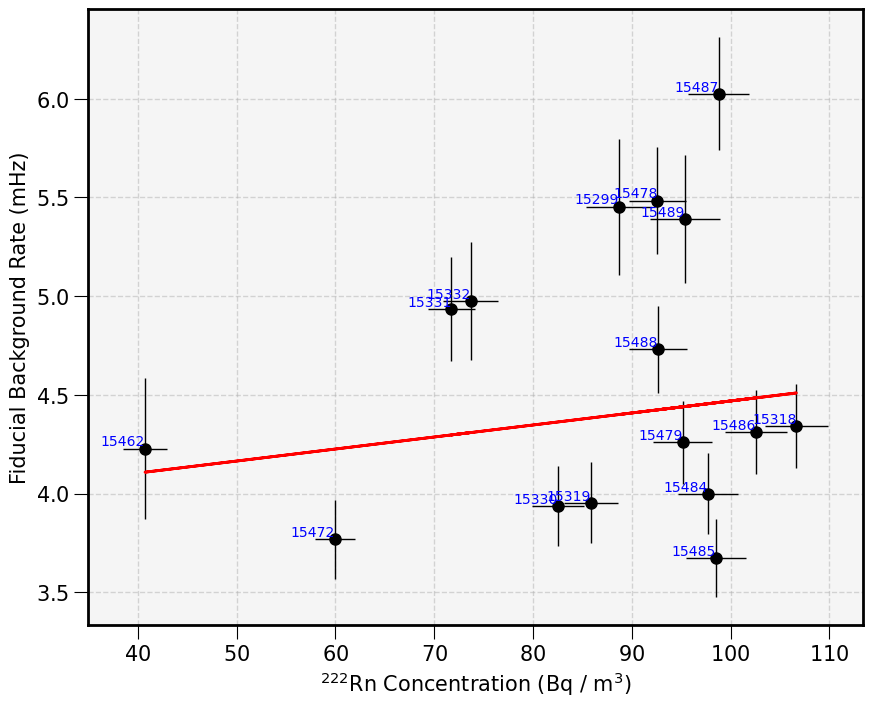

In [42]:
# ----- Linear Fit ----- #
# Preliminary
x_data   = np.array(Rn_LSC_CV)
x_errors = np.array(Rn_LSC_Err)
y_data   = np.array([Fiducial_Info[run_id]['rate_CV']    for run_id in Fiducial_Info.keys()])
y_errors = np.array([Fiducial_Info[run_id]['rate_Error'] for run_id in Fiducial_Info.keys()])

# Define the cost function
least_squares = LeastSquares(x_data, y_data, y_errors, ff.linear_func)

# Define the Minuit object with inital guesses for the parameters
m = Minuit(least_squares, m=10, b=0)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Reduced chi-square
chi2 = m.fval
ndof = len(x_data) - m.nfit
p_value = scipy.stats.chi2.sf(chi2, ndof)

print (f"Fit results:\n"
       f"  m = {m.values['m']:.6f} ± {m.errors['m']:.6f}\n"
       f"  b = ({m.values['b']:.2f} ± {m.errors['b']:.2f}) mHz\n"
       f"χ² / ndof = {chi2:.2f} / {ndof:.2f} = {chi2 / ndof:.2f}\n"
       f"p-value = {p_value:.2f}")

# ----- Plotting ----- #
fig, ax = plt.subplots()
# Data
plt.errorbar(x_data, y_data, xerr=x_errors, yerr=y_errors, fmt='o', color='black', ecolor='black', lw=1.0, label='Data')
for x, y, run_id in zip(x_data, y_data, Fiducial_Info.keys()):
    plt.text(x, y, str(run_id), fontsize=10, ha='right', va='bottom', color='blue')

# Fit
y_fit = ff.linear_func(x_data, m.values['m'], m.values['b'])
plt.plot(x_data, y_fit, color='red', ls='-', label=f"Linear fit\nb = ({m.values['b']:.2f} ± {m.errors['b']:.2f}) mHz\nχ² / ndof = {chi2 / ndof:.2f}")

# ----- Styling ----- #
# Important text
# plt.text(115.5, 5.5, f'intercept R = ({m.values["b"]:.2f} ± {m.errors["b"]:.2f}) mHz', va='bottom', ha='right')  # RAS = off (57.5, 5.45)

# # Preliminary logo
# LOGO_BOX  = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (108, 4.9)       # RAS = off (65, 5.6)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.ylabel('Fiducial Background Rate (mHz)')
plt.xlabel(r'$^{222}$Rn Concentration (Bq / m$^3$)')
# plt.ylim(2.4, 5)        # RAS = off (3.25, 5.75)
# plt.legend()

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/RAS_On_Corr.pdf')
plt.show()

## RAS: ON

Fit results:
  b = (3.63 ± 0.05) mHz
χ² / ndof = 22.99 / 24.00 = 0.96
p-value = 0.52


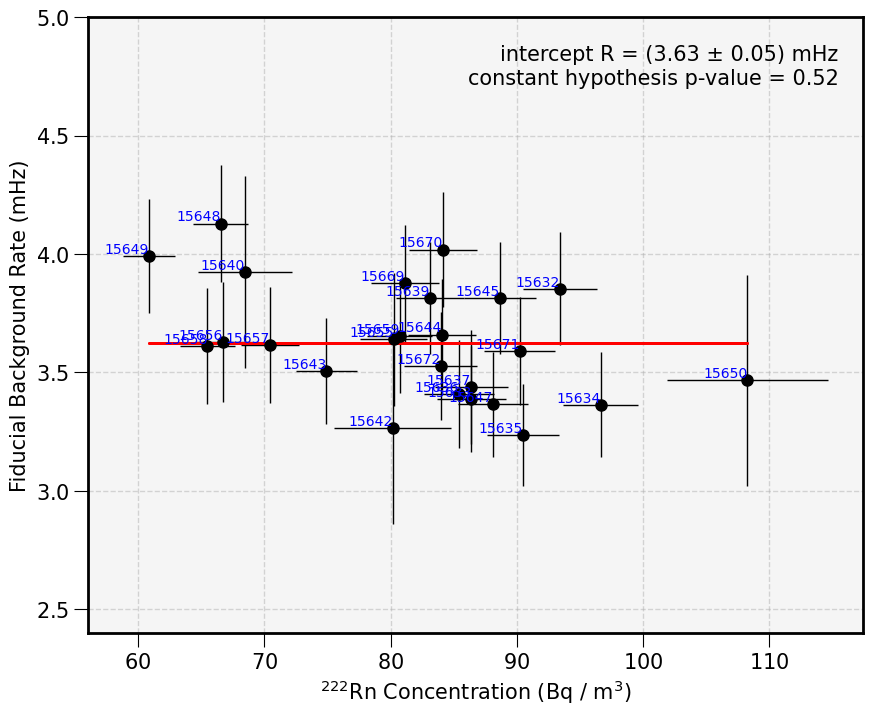

In [24]:
def const_func(x, b):
    return ff.linear_func(x, 0, b)

# ----- Linear Fit ----- #
# Preliminary
x_data   = np.array(Rn_LSC_CV)
x_errors = np.array(Rn_LSC_Err)
y_data   = np.array([Fiducial_Info[run_id]['rate_CV']    for run_id in Fiducial_Info.keys()])
y_errors = np.array([Fiducial_Info[run_id]['rate_Error'] for run_id in Fiducial_Info.keys()])

# Define the cost function
least_squares = LeastSquares(x_data, y_data, y_errors, const_func)

# Define the Minuit object with inital guesses for the parameters
m = Minuit(least_squares, b=0)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Reduced chi-square
chi2 = m.fval
ndof = len(x_data) - m.nfit
p_value = scipy.stats.chi2.sf(chi2, ndof)

print (f"Fit results:\n"
       f"  b = ({m.values['b']:.2f} ± {m.errors['b']:.2f}) mHz\n"
       f"χ² / ndof = {chi2:.2f} / {ndof:.2f} = {chi2 / ndof:.2f}\n"
       f"p-value = {p_value:.2f}")

# ----- Plotting ----- #
fig, ax = plt.subplots()
# Data
plt.errorbar(x_data, y_data, xerr=x_errors, yerr=y_errors, fmt='o', color='black', ecolor='black', lw=1.0, label='Data')
for x, y, run_id in zip(x_data, y_data, Fiducial_Info.keys()):
    plt.text(x, y, str(run_id), fontsize=10, ha='right', va='bottom', color='blue')

# Fit
y_fit = const_func(x_data, m.values['b'])
plt.plot(x_data, y_fit, color='red', ls='-', label=f"Linear fit\nb = ({m.values['b']:.2f} ± {m.errors['b']:.2f}) mHz\nχ² / ndof = {chi2 / ndof:.2f}")

# ----- Styling ----- #
# Important text
plt.text(115.5, 4.8, f'intercept R = ({m.values["b"]:.2f} ± {m.errors["b"]:.2f}) mHz', va='bottom', ha='right')  # RAS = off (57.5, 5.45)
plt.text(115.5, 4.7, f'constant hypothesis p-value = {p_value:.2f}', va='bottom', ha='right')

# # Preliminary logo
# LOGO_BOX  = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (108, 4.9)       # RAS = off (65, 5.6)
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(0, 0), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.ylabel('Fiducial Background Rate (mHz)')
plt.xlabel(r'$^{222}$Rn Concentration (Bq / m$^3$)')
plt.ylim(2.4, 5)        # RAS = off (3.25, 5.75)
# plt.legend()

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/RAS_On_Corr.pdf')
plt.show()